In [169]:
import pandas as pd
import numpy as np

In [170]:
df = pd.read_csv("placement.csv")

In [171]:
df.shape

(100, 4)

In [172]:
df = df.iloc[:,1:]

In [173]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


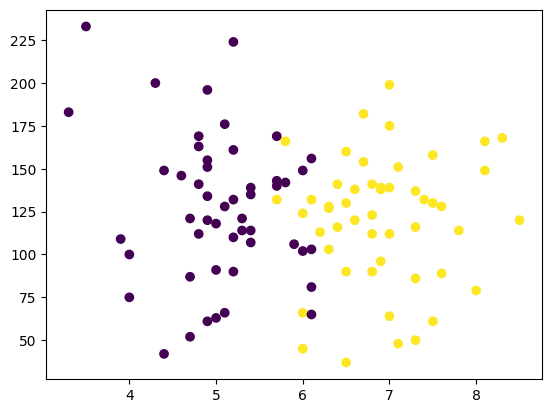

In [175]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [176]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]


In [177]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [178]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [179]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [180]:
X_train

,cgpa,iq
68,4.0,75.0
35,6.8,90.0
47,5.2,161.0
44,7.5,61.0
93,6.8,112.0
...,...,...
86,5.1,128.0
52,7.0,175.0
0,6.8,123.0
34,4.8,163.0


In [181]:
X_test

,cgpa,iq
99,6.2,113.0
12,5.4,139.0
76,4.9,155.0
57,6.5,130.0
16,5.2,224.0
89,4.9,151.0
66,6.9,96.0
4,5.8,142.0
81,5.4,107.0
19,5.2,132.0


In [182]:
y_train

,placement
68,0
35,1
47,0
44,1
93,1
...,...
86,0
52,1
0,1
34,0


In [183]:
y_test

,placement
99,1
12,0
76,0
57,1
16,0
89,0
66,1
4,0
81,0
19,0


In [184]:
from sklearn.preprocessing import StandardScaler

In [185]:
scaler=StandardScaler()

In [186]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [187]:
X_train

array([[-1.73049776, -1.17179124],
       [ 0.6563957 , -0.79684027],
       [-0.70754342,  0.9779277 ],
       [ 1.25311906, -1.52174549],
       [ 0.6563957 , -0.24691216],
       [ 0.40065712, -0.79684027],
       [-0.70754342, -0.29690563],
       [ 0.23016473,  0.15303555],
       [ 1.50885765, -0.1969187 ],
       [-0.963282  , -1.52174549],
       [ 0.57114951,  0.80295058],
       [-1.47475917,  1.95280025],
       [ 0.40065712,  0.95293097],
       [ 1.25311906,  0.90293751],
       [ 0.6563957 ,  0.47799306],
       [ 0.7416419 ,  0.40300287],
       [ 1.33836526, -0.821837  ],
       [ 1.08262667, -1.79670954],
       [-0.28131244,  0.25302248],
       [-0.62229722, -0.1969187 ],
       [-0.02557386,  0.67796692],
       [-1.0485282 ,  0.47799306],
       [ 1.08262667,  0.37800614],
       [-1.0485282 ,  1.17790156],
       [-0.19606625,  1.10291136],
       [-0.79278961,  1.35287868],
       [ 0.91213429, -1.84670301],
       [ 0.31541092, -0.14692524],
       [-0.02557386,

In [188]:
X_test

array([[ 0.85758945, -0.77003912],
       [-0.36753834,  0.00297312],
       [-1.1332432 ,  0.47867297],
       [ 1.31701237, -0.26460804],
       [-0.67382028,  2.53012854],
       [-1.1332432 ,  0.35974801],
       [ 1.92957626, -1.27547021],
       [ 0.24502556,  0.09216684],
       [-0.36753834, -0.94842656],
       [-0.67382028, -0.20514556]])

In [189]:
from sklearn.linear_model import LogisticRegression

In [190]:
clf=LogisticRegression()

In [191]:
clf.fit(X_train,y_train)

LogisticRegression()

In [192]:
y_predict=clf.predict(X_test)

In [193]:
y_test

,placement
99,1
12,0
76,0
57,1
16,0
89,0
66,1
4,0
81,0
19,0


In [194]:
from sklearn.metrics import accuracy_score

In [195]:
accuracy_score(y_test,y_predict)

0.9

In [199]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

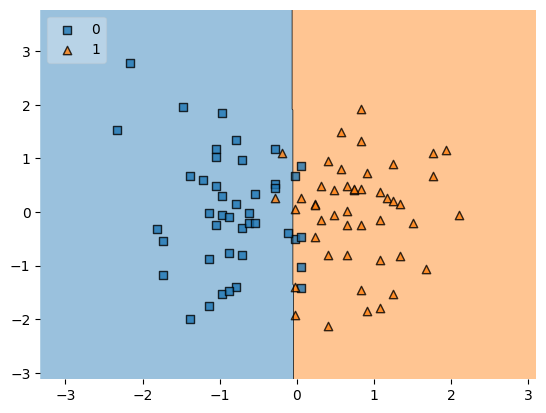

In [201]:
plot_decision_regions(X_train,y_train.values,clf=clf,legend=2)

In [202]:
import pickle

In [203]:
pickle.dump(clf,open('model.pkl','wb'))